<h1> <font color="blue"> <center> CVEN 5370 GIS Application in Civil Engineering</h1>
<h1> <font color="Red"> <center> Abdul Rehman</h1>

<hr>

<h1> Problem Statement</H1>

<h5> The goal is to create a logistic regression model for predicting bridge condition (suspectibility to failure). We shall use Age, ADT, Material, Reconstruct as our **independent variables** We shall recode the lowest bridge rating as 0 (satisfactory) and 1 (unsatisfactory) using the following scale Rating between [0-5] ( 1 or unsatisfactory) otherwise satisfactory

1. Read the 2024 data
2. Create latitudeDD and longitude DD for plotting
3. Create a new fid (lat_lon)
4. Clean or remove duplicates
5. Recode lowest rating as a binary variable 
6. Compute age
7. Extract the required variables into a new dataframe
8. Perform train-test split
9. Fit the model on training data
10. Evaluate the model using the testing data
11. Read 2025 data
12. Create new FID using the same concept as in step 3
13.  Exrtract unique bridges in 2025
14. Make prediction using the model fit in step 9 and compare
15. Make plots and maps for visualization and analysis

<h4> Code

In [35]:
# Import Libraries
import os
import pandas as pd
import numpy as np
import geopandas as gpd
from matplotlib import pyplot as plt
import statsmodels.api as sm
from shapely.geometry import Point, Polygon
#from matplotlib_map_utils.core.north_arrow import north_arrow


In [36]:
# Function to parse Lat and Long
def parsell(val, lat=True):
    s = str(val)

    # Determine degree/minute/second based on length
    if (len(s) == 8):
        degx = int(s[:2])
        minx = int(s[2:4])
        secx = int(s[4:]) / 100
    else:
        degx = int(s[:3])
        minx = int(s[3:5])
        secx = int(s[5:]) / 100
    if(lat==True):

    # Convert to decimal degrees
      dd = degx + minx / 60 + secx / 3600
      #  dd = degx + minx / 60 + secx / 3600


    # If it's longitude, assume it's west and make it negative
    else:
        dd = degx + minx / 60 + secx/3600
        dd = -1 * dd

    return (dd)


In [37]:
def dataprep(aa):    
    Rat = aa.copy()
    yrb = pd.to_numeric(aa.YEAR_BUILT_027, errors ="coerce")
    yrc = pd.to_numeric(aa.YEAR_RECONSTRUCTED_106, errors ="coerce")
    Rat["AGE"] = 2024 - np.maximum(yrb,yrc)
# Create lat long
    Rat["LATDD"] = parsellv(Rat["LAT_016"], lat=True)
    Rat["LONDD"] = parsellv(Rat["LONG_017"], lat=False)
    Rat["UNSAFE"] = np.where(Rat.loc[:,["LOWEST_RATING"]].astype(int)<6,1,0)
    return (Rat)

In [38]:
parsellv= np.vectorize(parsell)

In [39]:
path = '/home/fortbend/Assignment_4/Abdul'
os.chdir(path)

In [40]:
fname = '2024Data.csv'
a = pd.read_csv(fname,on_bad_lines='skip', dtype="str")
a.head()

,STATE_CODE_001,STRUCTURE_NUMBER_008,RECORD_TYPE_005A,ROUTE_PREFIX_005B,SERVICE_LEVEL_005C,ROUTE_NUMBER_005D,DIRECTION_005E,HIGHWAY_DISTRICT_002,COUNTY_CODE_003,PLACE_CODE_004,...,BRIDGE_LEN_IND_112,SCOUR_CRITICAL_113,FUTURE_ADT_114,YEAR_OF_FUTURE_ADT_115,MIN_NAV_CLR_MT_116,FED_AGENCY,SUBMITTED_BY,BRIDGE_CONDITION,LOWEST_RATING,DECK_AREA
0,48,0000000L2015318,1,6,4,00000,0,00,375,00000,...,Y,7,200,2035,NaN,Y,68,F,6,169.84
1,48,000021521-00101,1,6,0,00000,0,02,071,00000,...,Y,8,1,2042,NaN,Y,63,F,6,150.72
2,48,000021521-00181,1,6,0,00000,0,02,071,00000,...,Y,8,1,2042,NaN,Y,63,G,7,74.4
3,48,000021521-TMP20,1,6,1,00000,0,02,071,00000,...,Y,8,150,2042,NaN,Y,63,G,7,91.91
4,48,000021525-00012,1,6,0,00000,0,02,245,00000,...,Y,8,120,2042,NaN,Y,63,P,4,204.3


In [41]:
a.columns

Index(['STATE_CODE_001', 'STRUCTURE_NUMBER_008', 'RECORD_TYPE_005A',
       'ROUTE_PREFIX_005B', 'SERVICE_LEVEL_005C', 'ROUTE_NUMBER_005D',
       'DIRECTION_005E', 'HIGHWAY_DISTRICT_002', 'COUNTY_CODE_003',
       'PLACE_CODE_004',
       ...
       'BRIDGE_LEN_IND_112', 'SCOUR_CRITICAL_113', 'FUTURE_ADT_114',
       'YEAR_OF_FUTURE_ADT_115', 'MIN_NAV_CLR_MT_116', 'FED_AGENCY',
       'SUBMITTED_BY', 'BRIDGE_CONDITION', 'LOWEST_RATING', 'DECK_AREA'],
      dtype='object', length=123)

In [42]:
print(a.columns)

Index(['STATE_CODE_001', 'STRUCTURE_NUMBER_008', 'RECORD_TYPE_005A',
       'ROUTE_PREFIX_005B', 'SERVICE_LEVEL_005C', 'ROUTE_NUMBER_005D',
       'DIRECTION_005E', 'HIGHWAY_DISTRICT_002', 'COUNTY_CODE_003',
       'PLACE_CODE_004',
       ...
       'BRIDGE_LEN_IND_112', 'SCOUR_CRITICAL_113', 'FUTURE_ADT_114',
       'YEAR_OF_FUTURE_ADT_115', 'MIN_NAV_CLR_MT_116', 'FED_AGENCY',
       'SUBMITTED_BY', 'BRIDGE_CONDITION', 'LOWEST_RATING', 'DECK_AREA'],
      dtype='object', length=123)


In [43]:
a['FID'] = a.LAT_016.astype(str)+''+a.LONG_017.astype(str)
a['FID']

0        35185702101560762
1        29362100094272880
2        29362940094254920
3        29365160094324020
4        29413300094044860
               ...        
56724    31495329106183492
56725    32430233096561253
56726    32424987096560305
56727    32424560096561340
56728    29283700098252680
Name: FID, Length: 56729, dtype: object

In [44]:
#remove duplicate and create a copy
aa = a[~a.duplicated(subset=["FID"], keep=False)].copy()

In [45]:
aa.head()

,STATE_CODE_001,STRUCTURE_NUMBER_008,RECORD_TYPE_005A,ROUTE_PREFIX_005B,SERVICE_LEVEL_005C,ROUTE_NUMBER_005D,DIRECTION_005E,HIGHWAY_DISTRICT_002,COUNTY_CODE_003,PLACE_CODE_004,...,SCOUR_CRITICAL_113,FUTURE_ADT_114,YEAR_OF_FUTURE_ADT_115,MIN_NAV_CLR_MT_116,FED_AGENCY,SUBMITTED_BY,BRIDGE_CONDITION,LOWEST_RATING,DECK_AREA,FID
0,48,0000000L2015318,1,6,4,00000,0,00,375,00000,...,7,200,2035,NaN,Y,68,F,6,169.84,35185702101560762
1,48,000021521-00101,1,6,0,00000,0,02,071,00000,...,8,1,2042,NaN,Y,63,F,6,150.72,29362100094272880
2,48,000021521-00181,1,6,0,00000,0,02,071,00000,...,8,1,2042,NaN,Y,63,G,7,74.4,29362940094254920
3,48,000021521-TMP20,1,6,1,00000,0,02,071,00000,...,8,150,2042,NaN,Y,63,G,7,91.91,29365160094324020
4,48,000021525-00012,1,6,0,00000,0,02,245,00000,...,8,120,2042,NaN,Y,63,P,4,204.3,29413300094044860


In [46]:
#Create Lat Long
latx = aa.loc[:,["LAT_016"]]
aa.loc[:,"LATDD"] = parsellv(latx,lat=True)

In [47]:
longx= aa.loc[:,["LONG_017"]]
aa.loc[:,'LONDD'] = parsellv(longx, lat=False)

In [48]:
aa.LONDD

0       -101.935450
1        -94.458000
2        -94.430333
3        -94.544500
4        -94.080167
            ...    
56724   -106.309700
56725    -96.936814
56726    -96.934181
56727    -96.937056
56728    -98.424111
Name: LONDD, Length: 56571, dtype: float64

In [49]:
aa.LATDD

0        35.315839
1        29.605833
2        29.608167
3        29.614333
4        29.692500
           ...    
56724    31.831469
56725    32.717314
56726    32.713853
56727    32.712667
56728    29.476944
Name: LATDD, Length: 56571, dtype: float64

In [50]:
aa. LOWEST_RATING.describe()

count     56571
unique       10
top           7
freq      27960
Name: LOWEST_RATING, dtype: object

In [51]:
aa. LOWEST_RATING.unique()

array(['6', '7', '4', '8', '3', '5', '9', '2', '1', '0'], dtype=object)

In [52]:
Rat = aa.loc[:,["LOWEST_RATING"]].astype(int)
aa["UNSAFE"] = np.where (Rat<6,1,0)

In [53]:
aa.head()

,STATE_CODE_001,STRUCTURE_NUMBER_008,RECORD_TYPE_005A,ROUTE_PREFIX_005B,SERVICE_LEVEL_005C,ROUTE_NUMBER_005D,DIRECTION_005E,HIGHWAY_DISTRICT_002,COUNTY_CODE_003,PLACE_CODE_004,...,MIN_NAV_CLR_MT_116,FED_AGENCY,SUBMITTED_BY,BRIDGE_CONDITION,LOWEST_RATING,DECK_AREA,FID,LATDD,LONDD,UNSAFE
0,48,0000000L2015318,1,6,4,00000,0,00,375,00000,...,NaN,Y,68,F,6,169.84,35185702101560762,35.315839,-101.935450,0
1,48,000021521-00101,1,6,0,00000,0,02,071,00000,...,NaN,Y,63,F,6,150.72,29362100094272880,29.605833,-94.458000,0
2,48,000021521-00181,1,6,0,00000,0,02,071,00000,...,NaN,Y,63,G,7,74.4,29362940094254920,29.608167,-94.430333,0
3,48,000021521-TMP20,1,6,1,00000,0,02,071,00000,...,NaN,Y,63,G,7,91.91,29365160094324020,29.614333,-94.544500,0
4,48,000021525-00012,1,6,0,00000,0,02,245,00000,...,NaN,Y,63,P,4,204.3,29413300094044860,29.692500,-94.080167,1


In [54]:
sum(aa.UNSAFE)

4818

In [55]:
len(aa.UNSAFE)

56571

In [56]:
len(aa.UNSAFE) - sum(aa.UNSAFE)

51753

In [57]:
#calculate Age

In [58]:
#aa.dropna(inplace=True)

In [59]:
# Year_Build_027
# Year_ Recostructed_106
yrb= pd.to_numeric(aa.YEAR_BUILT_027, errors='coerce')
yrc= pd.to_numeric(aa.YEAR_RECONSTRUCTED_106, errors='coerce')
aa['AGE']= 2024 - np.maximum(yrb, yrc)



In [60]:
aa=aa.loc[aa["LATDD"]>25]
aa.head()

,STATE_CODE_001,STRUCTURE_NUMBER_008,RECORD_TYPE_005A,ROUTE_PREFIX_005B,SERVICE_LEVEL_005C,ROUTE_NUMBER_005D,DIRECTION_005E,HIGHWAY_DISTRICT_002,COUNTY_CODE_003,PLACE_CODE_004,...,FED_AGENCY,SUBMITTED_BY,BRIDGE_CONDITION,LOWEST_RATING,DECK_AREA,FID,LATDD,LONDD,UNSAFE,AGE
0,48,0000000L2015318,1,6,4,00000,0,00,375,00000,...,Y,68,F,6,169.84,35185702101560762,35.315839,-101.935450,0,16.0
1,48,000021521-00101,1,6,0,00000,0,02,071,00000,...,Y,63,F,6,150.72,29362100094272880,29.605833,-94.458000,0,19.0
2,48,000021521-00181,1,6,0,00000,0,02,071,00000,...,Y,63,G,7,74.4,29362940094254920,29.608167,-94.430333,0,19.0
3,48,000021521-TMP20,1,6,1,00000,0,02,071,00000,...,Y,63,G,7,91.91,29365160094324020,29.614333,-94.544500,0,12.0
4,48,000021525-00012,1,6,0,00000,0,02,245,00000,...,Y,63,P,4,204.3,29413300094044860,29.692500,-94.080167,1,17.0


In [61]:
aa.describe()

,LATDD,LONDD,UNSAFE,AGE
count,56570.000000,56570.000000,56570.000000,56514.000000
mean,31.224550,-97.512845,0.085169,37.289397
std,1.815607,2.262591,0.279135,22.415676
min,25.873389,-106.618869,0.000000,0.000000
25%,29.800444,-98.434671,0.000000,18.000000
50%,31.267235,-97.160800,0.000000,35.000000
75%,32.744215,-95.970334,0.000000,55.000000
max,36.482353,-93.520178,1.000000,124.000000


<Axes: >

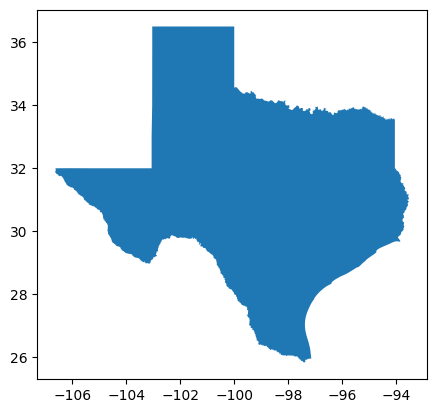

In [62]:
#txfile = "/home/fortbend/Lajuk/Data/TXdissolved.gpkg"
txfile = "TXdissolved.gpkg"
txbnd = gpd.read_file(txfile)
txdis = txbnd.dissolve()
txdis = txdis.to_crs(4326)
txdis.plot()

In [63]:
bridges = gpd.GeoDataFrame(aa,crs="EPSG:4326",
                           geometry = gpd.points_from_xy(aa['LONDD'], aa['LATDD']))


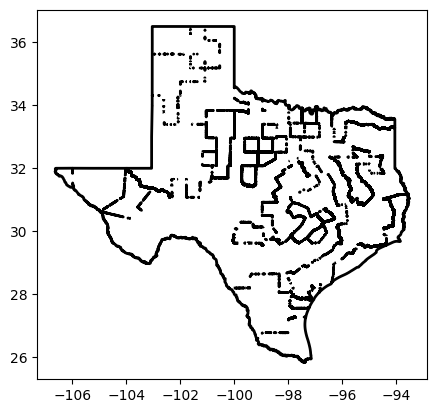

In [64]:
colormap= {0:"blue",1:"red"}
bridges["color"] = bridges["UNSAFE"].map(colormap)
fig,ax = plt.subplots()
txdis.plot(ax=ax,facecolor='none',edgecolor='black', linewidth=2)
plt.show()

In [65]:
len(txdis)

1

In [66]:
txdis # checking whether its is polygon or holes

,geometry,CMPTRL_CNT,DPS_CNTY_N,FIPS_ST_CN,TXDOT_CNTY,TXDOT_DIST,CNTY_NM,CNTY_NBR,DIST_NBR,GID,AreaSQMI
0,"POLYGON ((-102.32282 29.86645, -102.32274 29.8...",232,232,48463,232,15,Uvalde,232,15,35,1564.692024


In [67]:
#remove holes
# remove exterior polygon as geometry
#remove holes from single pol   Rat["LATDD"] = parsellv(Rat["LAT_016"], lat=True)
#Rat["LONDD"] = parsellv(Rat["LONG_017"], lat=False)
# Need polygon function from Shapely, import that
txdis["geometry"] = txdis["geometry"]. apply(lambda geom: Polygon(geom.exterior))

<Axes: >

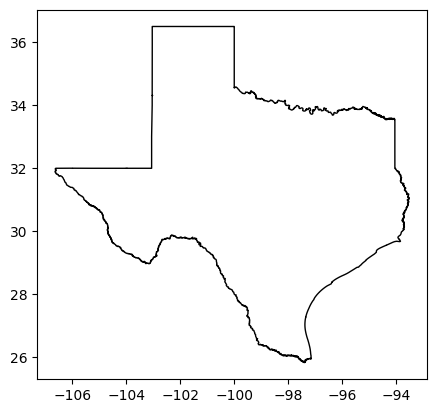

In [68]:
txdis = txdis.to_crs(4326)
txdis.plot(edgecolor='black', facecolor='none')

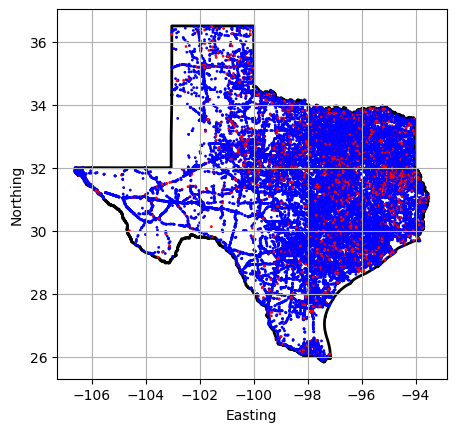

In [69]:
colormap= {0:"blue",1:"red"}
bridges["color"] = bridges["UNSAFE"].map(colormap)
fig,ax = plt.subplots()
txdis.plot(ax=ax,facecolor='none',edgecolor='black', linewidth=2)
bridges.plot(ax=ax, color=bridges["color"],markersize = 1)
ax.set_xlabel('Easting')
ax.set_ylabel('Northing')
plt.grid()
plt.show()

In [70]:
import sys
print(sys.version)

3.10.12 (main, Aug 15 2025, 14:32:43) [GCC 11.4.0]


In [71]:
#read the 2025 NBI file
fname ='2025Data.csv'
b=pd.read_csv(fname,on_bad_lines='skip',dtype="str")
len(b)

56951

In [72]:
# add FID based on Lat- Long
b['FID']= b.LAT_016.astype(str)+"_" + b.LONG_017.astype(str)
b['FID']

0        29362100_094272880
1        29362940_094254920
2        29365160_094324020
3        29413300_094044860
4        29412100_094092940
                ...        
56946    31495329_106183492
56947    32430233_096561253
56948    32424987_096560305
56949    32424560_096561340
56950    29283700_098252680
Name: FID, Length: 56951, dtype: object

In [73]:
bb = b[~b.duplicated(subset=['FID'], keep = False)].copy() #removing duplicates in same lat long
len(bb)

56847

In [74]:
new_records = bb[~bb["FID"].isin(aa["FID"])]
len (new_records)

56847

In [75]:
dat2025 = dataprep(new_records)

In [76]:
dat2025.head()

,STATE_CODE_001,STRUCTURE_NUMBER_008,RECORD_TYPE_005A,ROUTE_PREFIX_005B,SERVICE_LEVEL_005C,ROUTE_NUMBER_005D,DIRECTION_005E,HIGHWAY_DISTRICT_002,COUNTY_CODE_003,PLACE_CODE_004,...,FED_AGENCY,SUBMITTED_BY,BRIDGE_CONDITION,LOWEST_RATING,DECK_AREA,FID,AGE,LATDD,LONDD,UNSAFE
0,48,000021521-00101,1,6,0,00000,0,02,071,00000,...,Y,63,F,6,150.72,29362100_094272880,19.0,29.605833,-94.458000,0
1,48,000021521-00181,1,6,0,00000,0,02,071,00000,...,Y,63,G,7,74.4,29362940_094254920,19.0,29.608167,-94.430333,0
2,48,000021521-TMP20,1,6,1,00000,0,02,071,00000,...,Y,63,G,7,91.91,29365160_094324020,12.0,29.614333,-94.544500,0
3,48,000021525-00012,1,6,0,00000,0,02,245,00000,...,Y,63,P,4,204.3,29413300_094044860,17.0,29.692500,-94.080167,1
4,48,000021525-00014,1,6,0,00000,0,02,245,00000,...,Y,63,G,7,157.92,29412100_094092940,34.0,29.689167,-94.158167,0


In [77]:
aa.columns


Index(['STATE_CODE_001', 'STRUCTURE_NUMBER_008', 'RECORD_TYPE_005A',
       'ROUTE_PREFIX_005B', 'SERVICE_LEVEL_005C', 'ROUTE_NUMBER_005D',
       'DIRECTION_005E', 'HIGHWAY_DISTRICT_002', 'COUNTY_CODE_003',
       'PLACE_CODE_004',
       ...
       'FED_AGENCY', 'SUBMITTED_BY', 'BRIDGE_CONDITION', 'LOWEST_RATING',
       'DECK_AREA', 'FID', 'LATDD', 'LONDD', 'UNSAFE', 'AGE'],
      dtype='object', length=128)

In [78]:
#STRUCTURE KIND 043A, ADT 029, 'FID', 'LATDD', 'LONDD', 'UNSAFE', 'AGE' ;#YEAR_RECONSTRUCTED_106
aa["YEAR_RECONSTRUCTED_106"] = pd.to_numeric(aa["YEAR_RECONSTRUCTED_106"], errors='coerce')
aa["RECON"] = np.where(aa.YEAR_RECONSTRUCTED_106 > 0, 1, 0)
#dat2025["YEAR_RECONSTRUCTED_106"] = pd.to_numeric(dat2025["YEAR_RECONSTRUCTED_106"], errors='coerce')
#dat2025["RECON"] = np.where(dat2025.YEAR_RECONSTRUCTED_106> 0, 1, 0)


In [79]:
cols = ["FID", "LATDD", "LONDD", "AGE", "RECON", "ADT_029", "STRUCTURE_KIND_043A", "UNSAFE"]
#bb= aa.copy()
#bb=bb.loc[ :,cols]
#bb.to_csv('NBIFinal2024Data.csv' , index=False)56847
zz = aa.copy()
zz = zz.loc[:,cols]

In [80]:
#bb = dat2025.copy()
#bb = bb.loc[:, cols]   # Make sure 'cols' is defined and contains valid column names
#bb.to_csv('NBIUNIQUENBI2025.csv', index=False)


In [81]:
zznew = zz.rename(columns={'ADT_029':'ADT','STRUCTURE_KIND_043A':'MATL'})
zznew.to_csv('NBI2024LR.csv', index=False)